# L1 四大谱系
免疫、基质、上皮、其他

- 目标：将去批次后的合并数据在 L1 层划分为四大谱系：Immune / Epithelial / Stromal / Other。
- 方法：三条证据链（Marker 直读、Gene-set 打分、GPT 注释→标准化映射）多数合票。
- 产出：
    - obs['L1_lineage'], obs['L1lin_conf'], obs['L1lin_votes']

    - 审阅用表：L1_lineage_summary.csv

    - 注释后对象：06_L1_lineage_annotated.h5ad

## 环境与路径

In [1]:
import os, re
import numpy as np
import pandas as pd
import scanpy as sc
import omicverse as ov
from scipy.sparse import issparse
import matplotlib.pyplot as plt

# 数据根目录（按需修改）
DATA_ROOT = "/mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data"

# 输入（05：scVI 去批次结果）
SCVI_DIR = os.path.join(DATA_ROOT, "05_scvi_integrated")
IN_PATH  = os.path.join(SCVI_DIR, "tissue_dataset_scvi.h5ad")

# 输出（06：L1 注释结果）
ANNO_DIR = os.path.join(DATA_ROOT, "06_annotation"); os.makedirs(ANNO_DIR, exist_ok=True)
FIG_DIR  = os.path.join(ANNO_DIR, "figs");          os.makedirs(FIG_DIR,  exist_ok=True)
OUT_H5AD = os.path.join(ANNO_DIR, "06_L1_lineage_annotated.h5ad")
OUT_CSV  = os.path.join(ANNO_DIR, "L1_lineage_summary.csv")

# 关键键位
cluster_key = "leiden_scVI_0.2"
use_rep     = "X_scVI"
umap_key    = "X_umap"

# L1（谱系）列名
L1_cols = dict(
    marker="L1lin_marker",
    score ="L1lin_score",
    gpt   ="L1lin_gpt",
    final ="L1_lineage",
    conf  ="L1lin_conf",
    votes ="L1lin_votes"
)


/home/future/miniconda3/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## 读取数据并检查
确保聚类列与 UMAP 存在；若无 UMAP，则基于 X_scVI 快速计算

In [2]:
adata = sc.read_h5ad(IN_PATH)

if cluster_key not in adata.obs:
    raise ValueError(f"找不到聚类列 {cluster_key}")
if umap_key not in adata.obsm:
    sc.pp.neighbors(adata, use_rep=use_rep, n_neighbors=30)
    sc.tl.umap(adata)

cats = adata.obs[cluster_key].cat.categories if hasattr(adata.obs[cluster_key], "cat") \
       else sorted(adata.obs[cluster_key].unique(), key=str)

adata


AnnData object with n_obs × n_vars = 374507 × 3000
    obs: 'n_genes', 'GSM', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet', 'group', 'GSE', '_scvi_batch', '_scvi_labels', 'leiden_scVI_0.2', 'nn_div_GSM', 'nn_div_GSE'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'GSE_colors', 'REFERENCE_MANU', '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'leiden_scVI_0.2', 'leiden_scVI_0.2_colors', 'neighbors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

## 四大谱系
- Immune：T/B/NK/Myeloid/Plasma 的合并标志。

- Epithelial：结肠上皮核心标志。

- Stromal：基质合并（Fibroblast + SmoothMuscle + Endothelial）

- Other：神经/胶质等其他类（可在 L2 细分）。
- Core 用于可视化；Extended 加强 score 的鲁棒性。

In [3]:
# Core（紧凑，可视化）
L1_core = {
    "Immune":     ["PTPRC","CD3D","CD3E","CD2","CD79A","MS4A1","NKG7","GNLY","PRF1","LYZ"],
    "Epithelial": ["EPCAM","KRT8","KRT18","KRT19","KRT20","MUC2","TFF3"],
    "Stromal":    ["COL1A1","COL3A1","DCN","LUM","PDGFRA","ACTA2","TAGLN","MYH11","PECAM1","VWF"],
    "Other":      ["RBFOX3","TUBB3","SNAP25","MAP2","UCHL1","PLP1","SOX10","S100B","MBP"]
}

L1_ext = {
    "Immune": [
        "PTPRC","CD3D","CD3E","CD2","CD247","IL7R","CCR7","CD8A","CD4",
        "CD79A","CD79B","MS4A1","BANK1","CD19","CD74",
        "NKG7","GNLY","PRF1","GZMB","GZMH","KLRD1","KLRK1","FGFBP2",
        "LYZ","LST1","S100A8","S100A9","FCGR3A","TYROBP","CTSS","ITGAM",
        "XBP1","JCHAIN","MZB1","IGKC","IGHG1"
    ],
    "Epithelial": [
        "EPCAM","CDH1","CLDN3","CLDN4","OCLN",
        "KRT8","KRT18","KRT19","KRT20","MUC2","MUC13","TFF3",
        "ALPI","CA1","FABP1","FABP2","REG4","BEST4","AGR2","VIL1","SLC26A3","SPINK4","CEACAM5"
    ],
    "Stromal": [
        "COL1A1","COL1A2","COL3A1","COL6A1","COL6A2","DCN","LUM","FBLN1","PDGFRA","PDGFRB",
        "ACTA2","TAGLN","MYH11","MYL9","TPM2","CNN1",
        "VIM","DES","SPARC","FAP",
        "PECAM1","VWF","CDH5","ENG","ESAM","KDR","FLT1","PROX1","LYVE1","CLDN5"
    ],
    "Other": [
        "RBFOX3","TUBB3","SNAP25","SYT1","STMN2","UCHL1","MAP2","NEFL","NEFM","RBFOX1","ELAVL3",
        "SLC17A6","GAD1","GAD2","PLP1","SOX10","MPZ","MBP","PMP22","ERBB3","FABP7","CDH19",
        "GFAP","S100B","PHOX2B","HAND2","RET","ASCL1","CHAT","SLC18A3","SLC5A7","NOS1","VIP","CALB1","CALB2","TAC1","PENK"
    ]
}

def filter_panel(panel, varnames):
    return {k:[g for g in v if g in varnames] for k,v in panel.items()}

L1_core_f = filter_panel(L1_core, adata.var_names)
L1_ext_f  = filter_panel(L1_ext,  adata.var_names)

# score 使用 core∪ext；可视化用 core
L1_score_sets = {k: sorted(list(set(L1_core_f.get(k, []) + L1_ext_f.get(k, [])))) for k in L1_core.keys()}
core_markers  = sorted({g for v in L1_core_f.values() for g in v})


## marker 检查

查看过滤后每个谱系的可用 marker 数；若 Other(Neural) 太少，可临时不参与 Marker/Score 投票（GPT 仍可映射至 Other）

In [4]:
def panel_stats(core, ext, core_f, ext_f):
    rows = []
    for k in core.keys():
        core_total = len(core[k]);  ext_total = len(ext[k])
        core_kept  = len(core_f.get(k, [])); ext_kept  = len(ext_f.get(k, []))
        kept_union = len(set(core_f.get(k, []) + ext_f.get(k, [])))
        rows.append(dict(
            lineage=k,
            core_total=core_total, core_kept=core_kept, core_cov=core_kept/(core_total or 1),
            ext_total=ext_total,   ext_kept=ext_kept,   ext_cov=ext_kept/(ext_total or 1),
            union_kept=kept_union
        ))
    return pd.DataFrame(rows).sort_values("union_kept")

panel_df = panel_stats(L1_core, L1_ext, L1_core_f, L1_ext_f)
display(panel_df)

# Other(Neural) 的参与门槛
OTHER_MIN_MARKERS = 4
OTHER_ENABLED = panel_df.loc[panel_df["lineage"]=="Other","union_kept"].iloc[0] >= OTHER_MIN_MARKERS
if not OTHER_ENABLED:
    if "Other" in L1_score_sets: L1_score_sets.pop("Other", None)
    if "Other" in L1_core_f:     L1_core_f.pop("Other",     None)
    core_markers = sorted({g for v in L1_core_f.values() for g in v})
    print("⚠️ Other(Neural) 可用 marker < 4：本轮不参与 Marker/Score 投票（GPT 映射仍可落入 Other）。")
else:
    print("✅ Other(Neural) 参与 L1 投票。")

print(f"Core markers（过滤后，共 {len(core_markers)} 个）:")
print(core_markers)


,lineage,core_total,core_kept,core_cov,ext_total,ext_kept,ext_cov,union_kept
3,Other,9,2,0.222222,37,5,0.135135,5
1,Epithelial,7,6,0.857143,23,10,0.434783,10
2,Stromal,10,7,0.700000,30,19,0.633333,19
0,Immune,10,10,1.000000,36,31,0.861111,31


✅ Other(Neural) 参与 L1 投票。
Core markers（过滤后，共 25 个）:
['ACTA2', 'CD2', 'CD3D', 'CD3E', 'CD79A', 'COL1A1', 'COL3A1', 'DCN', 'EPCAM', 'GNLY', 'KRT18', 'KRT19', 'KRT20', 'KRT8', 'LYZ', 'MS4A1', 'MYH11', 'NKG7', 'PECAM1', 'PRF1', 'PTPRC', 'S100B', 'TAGLN', 'TFF3', 'UCHL1']


## 方法 A：Marker 直读（簇级评分）
思路：对每簇按谱系面板计算 均值表达 0.6 + 阳性占比 0.4，Top1 为该法标签；Top1-Top2 作为边距参考。

In [5]:
def _toarray(X): return X.toarray() if issparse(X) else X
def _pct_expr(adata, genes, mask):
    if len(genes)==0: return 0.0
    X = _toarray(adata[mask, genes].X); return float((X>0).mean())
def _mean_expr(adata, genes, mask):
    if len(genes)==0: return 0.0
    X = _toarray(adata[mask, genes].X); return float(X.mean())

marker_call, marker_gap = {}, {}
for cl in cats:
    mask = (adata.obs[cluster_key]==cl).values
    scores = {}
    for lin, genes in L1_score_sets.items():
        m = _mean_expr(adata, genes, mask)
        p = _pct_expr(adata, genes, mask)
        scores[lin] = 0.6*m + 0.4*p
    s = pd.Series(scores)
    top = s.sort_values(ascending=False).iloc[:2]
    marker_call[cl] = top.index[0] if len(top)>0 else "Other"
    marker_gap[cl]  = float(top.iloc[0] - top.iloc[1]) if len(top)==2 else float(top.iloc[0]) if len(top)==1 else 0.0

adata.obs[L1_cols["marker"]] = adata.obs[cluster_key].map(marker_call).astype("category")
adata.obs[L1_cols["marker"]+"_gap"] = adata.obs[cluster_key].map(marker_gap).astype(float)

marker_df = pd.DataFrame({
    "cluster": cats,
    "n_cells": [int((adata.obs[cluster_key]==cl).sum()) for cl in cats],
    "method":  ["marker"]*len(cats),
    "label":   [marker_call[cl] for cl in cats],
    "conf_gap":[marker_gap[cl]  for cl in cats]
}).sort_values(["label","cluster"])
display(marker_df)


,cluster,n_cells,method,label,conf_gap
2,2,64855,marker,Epithelial,1.488143
0,0,87837,marker,Immune,0.491823
10,10,3300,marker,Immune,0.143087
3,3,58928,marker,Immune,21.161552
4,4,30057,marker,Immune,0.860003
8,8,7243,marker,Immune,1.347493
7,7,7683,marker,Other,0.174464
1,1,72933,marker,Stromal,2.613213
5,5,26526,marker,Stromal,2.486169
6,6,10136,marker,Stromal,3.038779


## 方法 B：Gene-set 打分（score_genes → 簇均值）
思路：对每谱系做 score_genes，在簇内取均值，Top1 为该法标签；Top1-Top2 为边距。

In [6]:
for lin, genes in L1_score_sets.items():
    if len(genes)>0:
        sc.tl.score_genes(adata, gene_list=genes, score_name=f"score_L1lin_{lin}", use_raw=False)

score_call, score_gap = {}, {}
for cl in cats:
    mask = (adata.obs[cluster_key]==cl).values
    vals = {lin: adata.obs.loc[mask, f"score_L1lin_{lin}"].mean() if f"score_L1lin_{lin}" in adata.obs else -1e9
            for lin in L1_score_sets}
    s = pd.Series(vals)
    top = s.sort_values(ascending=False).iloc[:2]
    score_call[cl] = top.index[0] if len(top)>0 else "Other"
    score_gap[cl]  = float(top.iloc[0] - top.iloc[1]) if len(top)==2 else float(top.iloc[0]) if len(top)==1 else 0.0

adata.obs[L1_cols["score"]] = adata.obs[cluster_key].map(score_call).astype("category")
adata.obs[L1_cols["score"]+"_gap"] = adata.obs[cluster_key].map(score_gap).astype(float)

score_df = pd.DataFrame({
    "cluster": cats,
    "n_cells": [int((adata.obs[cluster_key]==cl).sum()) for cl in cats],
    "method":  ["score"]*len(cats),
    "label":   [score_call[cl] for cl in cats],
    "conf_gap":[score_gap[cl]  for cl in cats]
}).sort_values(["label","cluster"])
display(score_df)


,cluster,n_cells,method,label,conf_gap
2,2,64855,score,Epithelial,2.059456
0,0,87837,score,Immune,0.371321
10,10,3300,score,Immune,0.076035
3,3,58928,score,Immune,34.142471
4,4,30057,score,Immune,0.965033
8,8,7243,score,Immune,1.905977
7,7,7683,score,Other,0.798854
1,1,72933,score,Stromal,3.191011
5,5,26526,score,Stromal,2.969087
6,6,10136,score,Stromal,3.692131


## 方法 C：GPT 注释 → 标准化映射到四大谱系
要点：GPT 原始输出是自由文本，需映射到 {Immune, Epithelial, Stromal, Other}，再参与合票。

In [7]:
# 若无 rank_genes_groups（按 cluster_key），先计算
if 'rank_genes_groups' not in adata.uns or adata.uns['rank_genes_groups'].get('params',{}).get('groupby',None)!=cluster_key:
    sc.tl.rank_genes_groups(adata, groupby=cluster_key, method='wilcoxon', n_genes=200)

# 每簇前10个标记基因
all_markers = ov.single.get_celltype_marker(
    adata, clustertype=cluster_key, rank=True, key='rank_genes_groups', foldchange=1, topgenenumber=10
)

# GPT 识别（需 AGI_API_KEY 已在环境变量中）
os.environ['AGI_API_KEY'] = 'sk-b54d8fd2ec144ce78b32602024fba248'
gpt_raw = ov.single.gptcelltype(
    all_markers, tissuename='colon tissue', speciename='human',
    model='qwen-plus', provider='qwen', topgenenumber=10
)  # dict: {cluster -> free-text label}

# —— 将 GPT 自由文本映射到四大谱系 ——
SYNS = {
    "immune":     ["immune","lymphocyte","t cell","t-cell","b cell","b-cell","nk cell","nk-cell",
                   "plasma cell","plasma cells","macrophage","monocyte","dendritic","myeloid"],
    "epithelial": ["epithelial","epithelium","enterocyte","goblet","tuft","enteroendocrine","eec","best4"],
    "stromal":    ["stromal","mesenchymal","fibroblast","myofibroblast","smooth muscle","smc",
                   "endothelial","lymphatic","blood endothelial","pericyte","perivascular"],
    "other":      ["neural","neuron","neurons","glia","glial","schwann","enteric",
                   "astrocyte","oligodendro","unknown","uncertain","unassigned"]
}

def normalize_text(s: str) -> str:
    s = s.lower()
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def map_to_lineage(gpt_label: str) -> str:
    if not isinstance(gpt_label, str) or len(gpt_label)==0:
        return "Other"
    t = normalize_text(gpt_label)
    for lin, keys in SYNS.items():
        for k in keys:
            if k in t:
                return lin.capitalize()
    # 兜底规则
    if "macroph" in t or "monocyte" in t or "myeloid" in t or "dendrit" in t or "nk" in t or "plasma" in t:
        return "Immune"
    if "epi" in t:
        return "Epithelial"
    if "fibro" in t or "mesench" in t or "smooth" in t or "endo" in t or "pericy" in t:
        return "Stromal"
    if "neuro" in t or "glia" in t or "schwann" in t:
        return "Other"
    return "Other"

gpt_std_map = {cl: map_to_lineage(gpt_raw.get(cl, "")) for cl in cats}
adata.obs["L1lin_gpt_raw"] = adata.obs[cluster_key].map(gpt_raw).astype("category")
adata.obs[L1_cols["gpt"]]   = adata.obs[cluster_key].map(gpt_std_map).astype("category")

gpt_df = pd.DataFrame({
    "cluster": cats,
    "n_cells": [int((adata.obs[cluster_key]==cl).sum()) for cl in cats],
    "method":  ["gpt"]*len(cats),
    "label":   [gpt_std_map[cl] for cl in cats],
    "conf_gap":[np.nan]*len(cats)
}).sort_values(["label","cluster"])
display(gpt_df)


...get cell type marker
key already in adata.uns!
Note: AGI API key found: returning the cell type annotations.
Note: It is always recommended to check the results returned by GPT-4 in case of AI hallucination, before going to downstream analysis.


,cluster,n_cells,method,label,conf_gap
2,2,64855,gpt,Epithelial,NaN
0,0,87837,gpt,Immune,NaN
10,10,3300,gpt,Immune,NaN
3,3,58928,gpt,Immune,NaN
4,4,30057,gpt,Immune,NaN
8,8,7243,gpt,Immune,NaN
7,7,7683,gpt,Other,NaN
1,1,72933,gpt,Stromal,NaN
5,5,26526,gpt,Stromal,NaN
6,6,10136,gpt,Stromal,NaN


## 三法合票与置信度
- 合票：Marker / Score / GPT 多数票；
- 置信度：多数票比例（1/3、2/3、1.0）；
- 阈值：L1lin_conf < 0.6 → 统一归为 Other，留给 L2 细分。

In [8]:
methods = [L1_cols["marker"], L1_cols["score"], L1_cols["gpt"]]
per_cluster_votes, per_cluster_conf = {}, {}

for cl in cats:
    v = []
    for mcol in methods:
        lab = adata.obs.loc[adata.obs[cluster_key]==cl, mcol].mode(dropna=True)
        lab = str(lab.iloc[0]) if len(lab)>0 else None
        if lab in [None,"nan","None"]: continue
        v.append(lab)
    if len(v)==0:
        final, conf = "Other", 0.0
    else:
        vc = pd.Series(v).value_counts()
        final = vc.index[0]
        conf  = float(vc.iloc[0]/vc.sum())
    per_cluster_votes[cl] = final
    per_cluster_conf[cl]  = conf

adata.obs[L1_cols["final"]] = adata.obs[cluster_key].map(per_cluster_votes).astype("category")
adata.obs[L1_cols["conf"]]  = adata.obs[cluster_key].map(per_cluster_conf).astype(float)
adata.obs[L1_cols["votes"]] = "marker+score+gpt"

LOW_CONF_TH = 0.6
adata.obs.loc[adata.obs[L1_cols["conf"]] < LOW_CONF_TH, L1_cols["final"]] = "Other"

# 全量汇总表（按置信度升序便于复核）
vote_df = pd.DataFrame({
    "cluster": cats,
    "n_cells": [int((adata.obs[cluster_key]==cl).sum()) for cl in cats],
    "marker":      [adata.obs.loc[adata.obs[cluster_key]==cl, L1_cols["marker"]].mode().iloc[0] for cl in cats],
    "marker_gap":  [adata.obs.loc[adata.obs[cluster_key]==cl, L1_cols["marker"]+"_gap"].mean() for cl in cats],
    "score":       [adata.obs.loc[adata.obs[cluster_key]==cl, L1_cols["score"]].mode().iloc[0] for cl in cats],
    "score_gap":   [adata.obs.loc[adata.obs[cluster_key]==cl, L1_cols["score"]+"_gap"].mean() for cl in cats],
    "gpt":         [adata.obs.loc[adata.obs[cluster_key]==cl, L1_cols["gpt"]].mode().iloc[0] for cl in cats],
    "L1_lineage":  [per_cluster_votes[cl] for cl in cats],
    "L1_conf":     [per_cluster_conf[cl]  for cl in cats]
}).sort_values(["L1_conf","n_cells"], ascending=[True, True])
display(vote_df)


,cluster,n_cells,marker,marker_gap,score,score_gap,gpt,L1_lineage,L1_conf
10,10,3300,Immune,0.143087,Immune,0.076035,Immune,Immune,1.0
9,9,5009,Stromal,0.455767,Stromal,0.292012,Stromal,Stromal,1.0
8,8,7243,Immune,1.347493,Immune,1.905977,Immune,Immune,1.0
7,7,7683,Other,0.174464,Other,0.798854,Other,Other,1.0
6,6,10136,Stromal,3.038779,Stromal,3.692131,Stromal,Stromal,1.0
5,5,26526,Stromal,2.486169,Stromal,2.969087,Stromal,Stromal,1.0
4,4,30057,Immune,0.860003,Immune,0.965033,Immune,Immune,1.0
3,3,58928,Immune,21.161552,Immune,34.142471,Immune,Immune,1.0
2,2,64855,Epithelial,1.488143,Epithelial,2.059456,Epithelial,Epithelial,1.0
1,1,72933,Stromal,2.613213,Stromal,3.191011,Stromal,Stromal,1.0


## 可视化：总体与可靠性
- UMAP：聚类 / 最终谱系 / 置信度；
- Dotplot：Core marker × 最终谱系；
- 可靠性图：簇大小 vs 置信度；方法一致性热图。

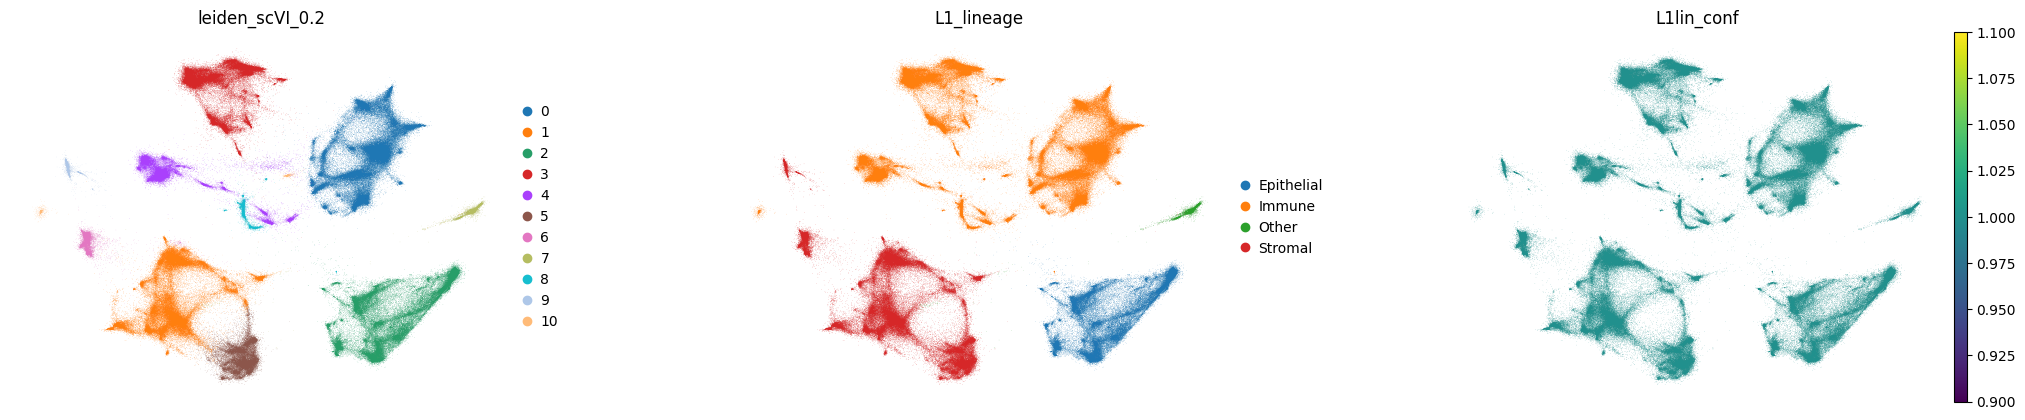

In [9]:
# UMAP
sc.pl.umap(adata, color=[cluster_key, L1_cols["final"], L1_cols["conf"]],
           wspace=0.3, frameon=False)

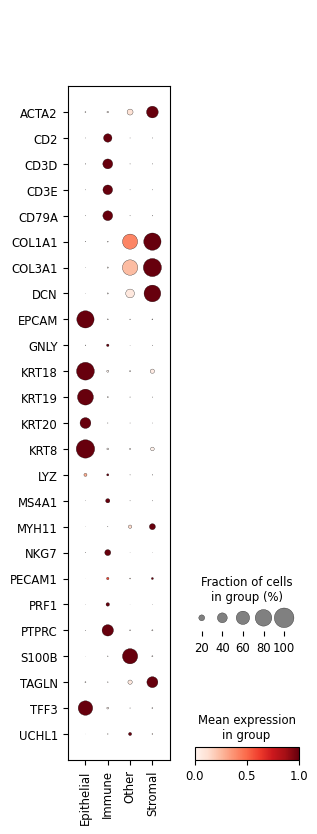

In [10]:
# Dotplot（按谱系）
if len(core_markers)>0:
    sc.pl.dotplot(adata, var_names=core_markers, groupby=L1_cols["final"],
                  standard_scale='var', swap_axes=True, dendrogram=False)

## 结果保存
说明：导出注释后的对象与审阅用表，供后续 L2 子集分析与复盘。

In [13]:
out_cols = [
    cluster_key,
    L1_cols["marker"], L1_cols["marker"]+"_gap",
    L1_cols["score"],  L1_cols["score"]+"_gap",
    "L1lin_gpt_raw",   L1_cols["gpt"],
    L1_cols["final"],  L1_cols["conf"], L1_cols["votes"]
]
adata.obs[out_cols].to_csv(OUT_CSV, index=True)
adata.write(OUT_H5AD)

print(f"[Done] L1 谱系注释完成：\n- 表: {OUT_CSV}\n- 对象: {OUT_H5AD}")

[Done] L1 谱系注释完成：
- 表: /mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data/06_annotation/L1_lineage_summary.csv
- 对象: /mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data/06_annotation/06_L1_lineage_annotated.h5ad
